# Economic Stakes

A Nash pricing counterfactual: what the estimator choice is worth

Dan Yavorsky  
Geoffery Zheng  
September 14, 2026

## What this notebook does

Every comparison so far has been statistical: variance ratios, RMSE, coverage. Those are the right units for a methods argument and the wrong units for a decision. This notebook converts them.

A synthetic market of five brands is simulated from the heterogeneous ordinal model. Four estimators are fit to the same data. Each estimator’s demand system is then pushed through the decision it exists to inform, a Nash pricing equilibrium, and we ask three questions of each:

1.  Where does it think the equilibrium is, versus where it truly is?
2.  How much profit does it *think* it will earn there, versus what actually materializes?
3.  How much profit is forgone relative to pricing at the true equilibrium?

The estimators, in decreasing order of how much of the second response they use:

| system | what it is |
|------------------------------------|------------------------------------|
| `ordinal` | the paper’s $W = 5$ model |
| `bin_t2b` | binary dual response, cut at top-2-box: the literature’s default, **well placed** |
| `bin_top` | binary dual response, cut at top box: the same method, badly placed |
| `heur_*` | choice-only MNL plus a **constant** purchase incidence: the common practitioner shortcut |

The heuristics come in two calibrations, textbook scale-point weights and a top-2-box count, to show the failure is structural rather than a matter of picking the right constant.

This notebook is the source of `counterfactual.rds`.

In [ ]:
#| label: setup
set.seed(1)
options(digits = 5)

## 1. Machinery

In [ ]:
#| label: machinery
#| code-fold: true
#| code-summary: "Simulator and the hierarchical sampler"
rgumbel <- function(n) -log(-log(runif(n)))
par_to_cut <- function(par, P, W) {
  if (W == 2) return(par[P + 1])
  par[P + 1] + c(0, cumsum(exp(par[(P + 2):(P + W - 1)])))
}
cut_to_par <- function(cut) if (length(cut) == 1) cut else c(cut[1], log(diff(cut)))
row_max <- function(M) do.call(pmax, as.data.frame(M))
ord_prob_z <- function(lo, hi, model) {
  if (model == "B") plogis(hi) * plogis(-lo) * (-expm1(lo - hi))
  else { ea <- exp(-lo); eb <- exp(-hi)
         p <- exp(-eb) * (-expm1(-(ea - eb))); p[!is.finite(eb)] <- 0; p }
}
id_rank_check <- function(X) { aug <- cbind(X, 1)
  list(rank = qr(aug)$rank, required = ncol(aug), pass = qr(aug)$rank == ncol(aug)) }
draw_betas <- function(N, beta_bar, Sigma, seed) {
  set.seed(seed); P <- length(beta_bar)
  sweep(matrix(rnorm(N*P), N, P) %*% chol(Sigma), 2, beta_bar, "+")
}
simulate_dual_hb <- function(design, Bmat, cut, model = c("A","B"), seed) {
  model <- match.arg(model); set.seed(seed)
  n <- design$n_tasks; J <- design$J; N <- design$N
  cutmat <- if (is.matrix(cut)) cut else matrix(cut, N, length(cut), byrow = TRUE)
  W <- ncol(cutmat) + 1L
  Bx <- Bmat[design$resp_row, , drop = FALSE]
  V <- matrix(rowSums(design$X * Bx), nrow = n, ncol = J, byrow = TRUE)
  u <- V + matrix(rgumbel(n * J), n, J)
  jstar <- max.col(u, ties.method = "first")
  ustar <- u[cbind(seq_len(n), jstar)]
  latent <- if (model == "A") ustar else ustar - rgumbel(n)
  list(design = design, resp = design$resp, resp_row = design$resp_row, N = N,
       jstar = jstar, y = as.integer(1L + rowSums(latent >= cutmat[design$resp, , drop = FALSE])),
       W = W, model = model, Bmat_true = Bmat, cut_true = cut)
}
phi_to_cutmat <- function(Phi, P, W) {
  c1 <- Phi[, P + 1]
  if (W == 2) return(matrix(c1, ncol = 1))
  D <- exp(Phi[, (P + 2):(P + W - 1), drop = FALSE])
  cm <- matrix(0, nrow(Phi), W - 1); cm[, 1] <- c1
  for (w in 2:(W - 1)) cm[, w] <- cm[, w - 1] + D[, w - 1]
  cm
}
resp_loglik_all <- function(dat, Bmat, cutmat, choice_only = FALSE) {
  des <- dat$design; n <- des$n_tasks; J <- des$J
  Bx <- Bmat[dat$resp_row, , drop = FALSE]
  V <- matrix(rowSums(des$X * Bx), nrow = n, ncol = J, byrow = TRUE)
  m <- row_max(V); logS <- m + log(rowSums(exp(V - m)))
  ll <- V[cbind(seq_len(n), dat$jstar)] - logS
  if (!choice_only) {
    ca <- cbind(-Inf, cutmat, Inf)
    ll <- ll + log(pmax(ord_prob_z(ca[cbind(dat$resp, dat$y)] - logS,
                                   ca[cbind(dat$resp, dat$y + 1L)] - logS,
                                   dat$model), 1e-312))
  }
  as.numeric(rowsum(ll, dat$resp, reorder = TRUE))
}
default_hb_priors <- function(d) list(phibar0 = rep(0, d), A = 1/100,
  nu = d + 3, V0 = (d + 3) * diag(d), zeta_prec = 1/100)
draw_phibar <- function(Phi, Sigma, pr) {
  N <- nrow(Phi); Si <- chol2inv(chol(Sigma))
  Vb <- chol2inv(chol(N * Si + pr$A * diag(ncol(Phi))))
  as.numeric(Vb %*% (Si %*% (N * colMeans(Phi)) + pr$A * pr$phibar0) +
             t(chol(Vb)) %*% rnorm(ncol(Phi)))
}
draw_sigma <- function(Phi, phibar, pr) {
  Vn <- pr$V0 + crossprod(sweep(Phi, 2, phibar))
  chol2inv(chol(rWishart(1, pr$nu + nrow(Phi), chol2inv(chol(Vn)))[,,1]))
}
fit_dual_hb <- function(dat, mcmc = list(R=30000, burn=10000, thin=10),
                        het_cut = FALSE, choice_only = FALSE, priors = NULL,
                        keep_phi = TRUE, seed = NULL, verbose = TRUE) {
  if (!is.null(seed)) set.seed(seed)
  des <- dat$design; N <- dat$N; P <- des$P; W <- dat$W
  dim_phi <- if (het_cut) P + W - 1 else P
  if (is.null(priors)) priors <- default_hb_priors(dim_phi)
  R_iter <- mcmc$R; burn <- mcmc$burn; thin <- mcmc$thin
  nkeep <- floor((R_iter - burn) / thin)
  Phi <- matrix(0, N, dim_phi)
  freq <- tabulate(dat$y, nbins = W)
  cumq <- pmin(pmax(cumsum(freq)[1:(W-1)]/sum(freq), 1e-4), 1-1e-4)
  ginv <- if (dat$model == "B") qlogis else function(q) -log(-log(q))
  cut0 <- log(des$J) + ginv(cumq)
  if (W > 2) for (k in 2:(W-1)) cut0[k] <- max(cut0[k], cut0[k-1] + 1e-3)
  zeta <- cut_to_par(cut0)
  if (het_cut) Phi[, (P+1):(P+W-1)] <- matrix(zeta, N, W-1, byrow = TRUE)
  phibar <- colMeans(Phi); Sigma <- diag(dim_phi)
  cur_cutmat <- if (het_cut) phi_to_cutmat(Phi, P, W) else
    matrix(par_to_cut(zeta, 0, W), N, W-1, byrow = TRUE)
  cur_ll <- resp_loglik_all(dat, Phi[, 1:P, drop=FALSE], cur_cutmat, choice_only)
  s_phi <- rep(2.93/sqrt(dim_phi), N); acc_phi <- rep(0, N)
  s_zeta <- 0.05; acc_zeta <- 0; window <- 100
  keep_betabar <- matrix(NA_real_, nkeep, dim_phi)
  keep_Sigma <- array(NA_real_, c(nkeep, dim_phi, dim_phi))
  keep_cut <- if (!het_cut && !choice_only) matrix(NA_real_, nkeep, W-1) else NULL
  keep_ll <- numeric(nkeep); keep_ll_resp <- matrix(NA_real_, nkeep, N)
  keep_Phi <- if (keep_phi) array(NA_real_, c(nkeep, N, dim_phi)) else NULL
  t0 <- Sys.time(); ki <- 0
  for (it in seq_len(R_iter)) {
    U <- chol(Sigma)
    Prop <- Phi + (matrix(rnorm(N*dim_phi), N, dim_phi) %*% U) * s_phi
    prop_cutmat <- if (het_cut) phi_to_cutmat(Prop, P, W) else cur_cutmat
    prop_ll <- resp_loglik_all(dat, Prop[, 1:P, drop=FALSE], prop_cutmat, choice_only)
    Si <- chol2inv(chol(Sigma))
    dcur <- sweep(Phi, 2, phibar); dprop <- sweep(Prop, 2, phibar)
    la <- (prop_ll - 0.5*rowSums((dprop %*% Si)*dprop)) -
          (cur_ll  - 0.5*rowSums((dcur  %*% Si)*dcur))
    acc <- log(runif(N)) < la
    Phi[acc, ] <- Prop[acc, ]; cur_ll[acc] <- prop_ll[acc]
    if (het_cut && any(acc)) cur_cutmat[acc, ] <- prop_cutmat[acc, , drop=FALSE]
    acc_phi <- acc_phi + acc
    if (!het_cut && !choice_only) {
      zp <- zeta + rnorm(W-1, sd = s_zeta)
      cp <- matrix(par_to_cut(zp, 0, W), N, W-1, byrow = TRUE)
      lp_ll <- resp_loglik_all(dat, Phi[, 1:P, drop=FALSE], cp, choice_only)
      if (log(runif(1)) < (sum(lp_ll) - 0.5*priors$zeta_prec*sum(zp^2)) -
                          (sum(cur_ll) - 0.5*priors$zeta_prec*sum(zeta^2))) {
        zeta <- zp; cur_cutmat <- cp; cur_ll <- lp_ll; acc_zeta <- acc_zeta + 1
      }
    }
    phibar <- draw_phibar(Phi, Sigma, priors); Sigma <- draw_sigma(Phi, phibar, priors)
    if (it <= burn && it %% window == 0) {
      s_phi <- pmin(pmax(s_phi*exp(1.5*(acc_phi/window - 0.23)), 0.01), 10); acc_phi <- rep(0, N)
      if (!het_cut && !choice_only) {
        s_zeta <- min(max(s_zeta*exp(1.5*(acc_zeta/window - 0.30)), 1e-3), 2); acc_zeta <- 0 }
    }
    if (it == burn) { acc_phi <- rep(0, N); acc_zeta <- 0 }
    if (it > burn && (it - burn) %% thin == 0) {
      ki <- ki + 1
      keep_betabar[ki, ] <- phibar; keep_Sigma[ki, , ] <- Sigma
      if (!is.null(keep_cut)) keep_cut[ki, ] <- par_to_cut(zeta, 0, W)
      keep_ll[ki] <- sum(cur_ll); keep_ll_resp[ki, ] <- cur_ll
      if (keep_phi) keep_Phi[ki, , ] <- Phi
    }
  }
  post <- R_iter - burn
  structure(list(draws = list(phibar = keep_betabar, Sigma = keep_Sigma,
                              cut = keep_cut, Phi = keep_Phi),
                 ll = keep_ll, ll_resp = keep_ll_resp,
                 accept = list(phi = mean(acc_phi/post),
                               zeta = if (het_cut || choice_only) NA else acc_zeta/post),
                 settings = list(mcmc = mcmc, het_cut = het_cut,
                                 choice_only = choice_only, P = P, W = W, N = N,
                                 model = dat$model, priors = priors),
                 runtime_min = as.numeric(difftime(Sys.time(), t0, units="mins"))),
            class = "dr_hb_fit")
}

## 2. The market

Five brands with their own intercepts, a three-level quality attribute, and price. Every task shows the full shelf. Costs are common, so differences in equilibrium price come entirely from demand.

In [ ]:
#| label: market
ITER <- 30000
MCMC <- list(R = ITER, burn = floor(0.4*ITER), thin = 10)
N <- 500; T_tasks <- 12; J <- 5; W <- 5; KBUY <- 4; NBRAND <- 5

beta_bar   <- c(b2=0.6, b3=0.4, b4=0.2, b5=-0.2, q2=0.5, q3=1.0, price=-1.4)
Sigma_true <- diag(c(0.5,0.5,0.5,0.5,0.3,0.4,0.3))
cut_true   <- c(-0.6, 0.5, 1.5, 2.7)
P <- length(beta_bar)
COST <- rep(0.9, NBRAND)
PRICE_GRID <- c(0.8, 1.2, 1.6, 2.0, 2.4)

make_market_design <- function(N, T_tasks, seed) {
  set.seed(seed)
  n <- N * T_tasks
  brand <- rep(1:NBRAND, times = n)
  qual  <- sample(1:3, n*J, replace = TRUE)
  price <- sample(PRICE_GRID, n*J, replace = TRUE)
  X <- cbind(b2 = as.numeric(brand == 2), b3 = as.numeric(brand == 3),
             b4 = as.numeric(brand == 4), b5 = as.numeric(brand == 5),
             q2 = as.numeric(qual == 2), q3 = as.numeric(qual == 3), price = price)
  list(X = X, n_tasks = n, J = J, P = ncol(X), N = N, T_tasks = T_tasks,
       resp = rep(seq_len(N), each = T_tasks),
       resp_row = rep(rep(seq_len(N), each = T_tasks), each = J))
}

des <- make_market_design(N, T_tasks, seed = 4001)
stopifnot(id_rank_check(des$X)$pass)
B_true <- draw_betas(N, beta_bar, Sigma_true, seed = 4002)
dat <- simulate_dual_hb(des, B_true, cut_true, model = "B", seed = 4003)
shares <- tabulate(dat$y, W) / length(dat$y)
cat("category shares:", round(shares, 3),
    " top-2-box:", round(sum(shares[4:5]), 3), "\n")

category shares: 0.265 0.204 0.203 0.179 0.15  top-2-box: 0.328 

## 3. Demand and equilibrium

Demand on a counterfactual shelf is the share who choose a brand times the probability they then buy:

$$
d_b(p) \;=\; \frac{1}{N}\sum_i \text{MNL}_{ib}(p) \times \Pr\!\left( y \ge 4 \mid \text{shelf}, p; i \right).
$$

The purchase event is defined **once**, as the top-2-box outcome of the true process, and every system is judged against that same physical event.

In [ ]:
#| label: demand
shelf_X <- function(p) cbind(
  b2 = c(0,1,0,0,0), b3 = c(0,0,1,0,0), b4 = c(0,0,0,1,0), b5 = c(0,0,0,0,1),
  q2 = rep(1,5), q3 = rep(0,5), price = p)

demand_model <- function(p, BigB, cut_row, link = "B") {
  V <- BigB %*% t(shelf_X(p))
  m <- do.call(pmax, as.data.frame(V)); eV <- exp(V - m); S <- rowSums(eV)
  G <- if (link == "B") plogis else function(z) exp(-exp(-z))
  colMeans((eV / S) * (1 - G(cut_row - (m + log(S)))))
}
# The heuristic: MNL shares times a CONSTANT incidence that cannot see price.
demand_heuristic <- function(p, BigB, incidence) {
  V <- BigB %*% t(shelf_X(p))
  m <- do.call(pmax, as.data.frame(V)); eV <- exp(V - m)
  colMeans(eV / rowSums(eV)) * incidence
}

ND_DRAWS <- 200
stack_draws <- function(fit, kpos = NULL) {
  nkeep <- dim(fit$draws$Phi)[1]
  idx <- unique(round(seq(1, nkeep, length.out = ND_DRAWS)))
  Pf <- fit$settings$P
  list(B = do.call(rbind, lapply(idx, function(r) fit$draws$Phi[r, , 1:Pf, drop = TRUE])),
       cut = if (!is.null(kpos))
         rep(fit$draws$cut[idx, kpos], each = dim(fit$draws$Phi)[2]) else NULL)
}

nash_prices <- function(demand_fn,
                        starts = list(rep(1.2,5), rep(2.0,5), c(0.9,1.3,1.7,2.1,2.4)),
                        damp = 0.5, tol = 1e-4, maxit = 200) {
  eqs <- lapply(starts, function(p0) {
    p <- p0
    for (it in seq_len(maxit)) {
      p_new <- p
      for (b in seq_len(NBRAND)) {
        br <- optimize(function(pb) { pp <- p_new; pp[b] <- pb
          -(demand_fn(pp)[b] * (pb - COST[b])) }, interval = c(COST[b], 4.5))
        p_new[b] <- (1 - damp)*p[b] + damp*br$minimum
      }
      if (max(abs(p_new - p)) < tol) break
      p <- p_new
    }
    p
  })
  list(p = eqs[[1]],
       spread = max(vapply(eqs, function(e) max(abs(e - eqs[[1]])), numeric(1))))
}

Using posterior *draws* rather than posterior means is deliberate. Posterior means shrink individual coefficients toward the population average, which flattens heterogeneity and would understate how sharply demand responds to price.

In [ ]:
#| label: truth
d_true <- function(p) demand_model(p, B_true, cut_true[KBUY - 1])
eq_true <- nash_prices(d_true)
elast <- vapply(seq_len(NBRAND), function(b) {
  p <- eq_true$p; h <- 0.01; p2 <- p; p2[b] <- p[b] + h
  (log(d_true(p2)[b]) - log(d_true(p)[b])) / (log(p2[b]) - log(p[b]))
}, numeric(1))
cat("true equilibrium prices:", round(eq_true$p, 3), "\n")

true equilibrium prices: 1.87 1.951 1.97 1.935 1.907 

own-price elasticities  : -1.93 -1.86 -1.84 -1.87 -1.9 

multi-start spread      : 0.000243 

Elasticities near $-2$ are in the range reported for branded consumer goods, so the market is not a caricature.

## 4. Fit the estimators

In [ ]:
#| label: fits
dichotomize <- function(dat, k) { dat$y <- 1L + (dat$y >= k); dat$W <- 2L; dat }

fit_ord <- fit_dual_hb(dat, mcmc = MCMC, seed = 5001, verbose = FALSE)
fit_t2b <- fit_dual_hb(dichotomize(dat, 4), mcmc = MCMC, seed = 5002, verbose = FALSE)
fit_top <- fit_dual_hb(dichotomize(dat, 5), mcmc = MCMC, seed = 5003, verbose = FALSE)
fit_mnl <- fit_dual_hb(dat, mcmc = MCMC, choice_only = TRUE, seed = 5004, verbose = FALSE)

wts_juster   <- c(0.05, 0.25, 0.50, 0.75, 0.95)   # textbook scale-point weights
incid_juster <- sum(shares * wts_juster)
incid_t2b    <- sum(shares[4:5])
cat(sprintf("heuristic incidences: juster weights %.3f, top-2-box count %.3f\n",
            incid_juster, incid_t2b))

heuristic incidences: juster weights 0.442, top-2-box count 0.328

## 5. Equilibria

In [ ]:
#| label: equilibria
results <- list()
for (nm in names(systems)) {
  eq <- nash_prices(systems[[nm]])
  d_hat  <- systems[[nm]](eq$p)     # what the system believes at its own p*
  d_real <- d_true(eq$p)            # what actually materializes there
  results[[nm]] <- list(p = eq$p, spread = eq$spread, d_hat = d_hat, d_real = d_real,
                        prof_hat = d_hat * (eq$p - COST),
                        prof_real = d_real * (eq$p - COST))
}
knitr::kable(do.call(rbind, lapply(names(systems), function(nm)
  data.frame(system = nm, t(round(results[[nm]]$p, 3)),
             `multi-start spread` = signif(results[[nm]]$spread, 2),
             check.names = FALSE))), row.names = FALSE)

  system              1       2       3       4       5   multi-start spread
  ------------- ------- ------- ------- ------- ------- --------------------
  truth           1.870   1.951   1.970   1.935   1.907              0.00024
  ordinal         1.886   1.946   1.928   1.917   1.881              0.00022
  bin_t2b         1.909   1.964   1.967   1.939   1.952              0.00026
  bin_top         1.977   1.986   2.000   1.967   1.948              0.00029
  heur_juster     1.711   1.942   1.878   1.866   1.774              0.00042
  heur_t2b        1.711   1.942   1.878   1.866   1.774              0.00042


In [ ]:
#| label: distortions
pt <- results$truth$p
prof_at_truth <- d_true(pt) * (pt - COST)
tab <- do.call(rbind, lapply(names(systems)[-1], function(nm) {
  r <- results[[nm]]
  data.frame(system = nm,
    mean_abs_price_err_pct  = 100 * mean(abs(r$p - pt) / pt),
    max_abs_price_err_pct   = 100 * max(abs(r$p - pt) / pt),
    profit_forecast_err_pct = 100 * mean((r$prof_hat - r$prof_real) / r$prof_real),
    profit_loss_vs_truth_pct = 100 * (sum(prof_at_truth) - sum(r$prof_real)) /
                                      sum(prof_at_truth))
}))
tab[-1] <- lapply(tab[-1], round, 2)
knitr::kable(tab, row.names = FALSE)

  -------------------------------------------------------------------------------------------------------------------
  system          mean_abs_price_err_pct   max_abs_price_err_pct   profit_forecast_err_pct   profit_loss_vs_truth_pct
  ------------- ------------------------ ----------------------- ------------------------- --------------------------
  ordinal                           1.11                    2.13                     -2.98                       0.37

  bin_t2b                           1.10                    2.38                     -2.47                      -0.31

  bin_top                           2.57                    5.73                    -59.29                      -0.84

  heur_juster                       4.84                    8.52                    105.82                       2.18

  heur_t2b                          4.84                    8.52                     52.94                       2.18
  -------------------------------------------------------------------------------------------------------------------


Three readings.

**The full ordinal model prices the market almost exactly.** No surprise given notebook 04, but it is the benchmark the others are measured against.

**The well-placed binary dual response also prices well.** This is worth saying plainly because it cuts against the paper’s thesis if read carelessly: when the analyst happens to dichotomize at the threshold the decision actually depends on, the binary model is nearly as good. The catch is in the next row.

**A badly placed cut misprices, and cannot be rescued.** `bin_top` models the top-box event, so $c_3$ is simply not identified from its data. Its error mixes estimation noise with a convention mismatch, which is precisely the cost of dichotomizing at the wrong cut. And the analyst must choose the cut *before* seeing the data.

**The constant-probability heuristic fails structurally.** Its purchase incidence cannot respond to price at all, so the extensive margin is flat by construction. Both calibrations fail the same way, which is the point: no choice of constant fixes a model in which the constant is the problem. Its equilibrium is the inside-good-only equilibrium, because a constant cancels from every best-response first-order condition. No amount of data repairs this.

## 6. Why the heuristic fails, in one picture

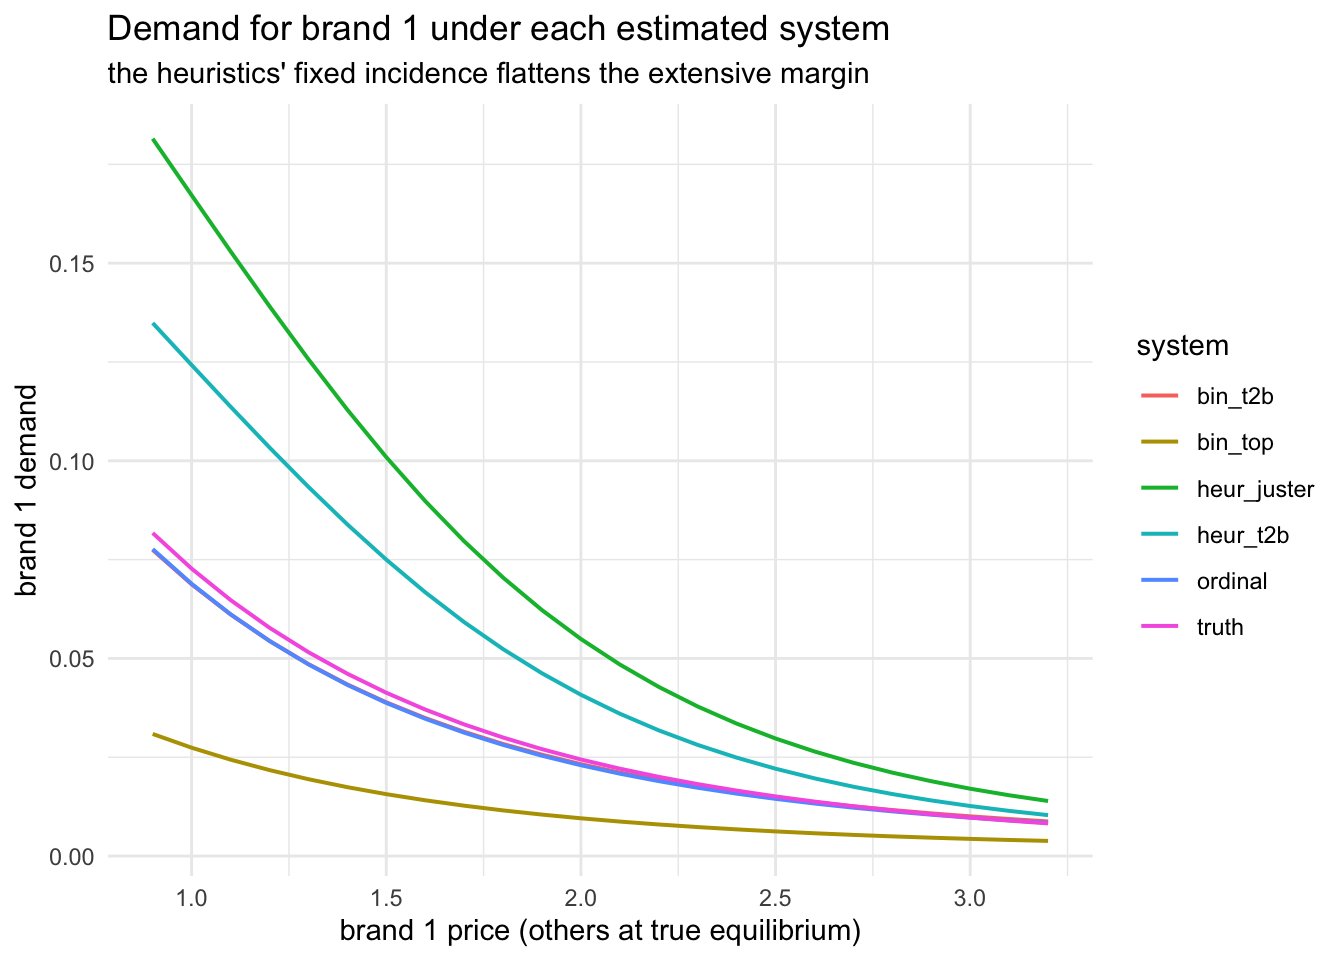

In [ ]:
#| label: fig-demand
#| fig-cap: "Demand for brand 1 as its price varies, other brands held at the true equilibrium."
pgrid <- seq(0.9, 3.2, by = 0.1)
dcurves <- do.call(rbind, lapply(names(systems), function(nm)
  data.frame(system = nm, p1 = pgrid,
             d1 = vapply(pgrid, function(pp) {
               p <- results$truth$p; p[1] <- pp; systems[[nm]](p)[1] }, numeric(1)))))
suppressMessages(library(ggplot2))
g <- ggplot(dcurves, aes(p1, d1, colour = system)) + geom_line(linewidth = 0.7) +
  labs(x = "brand 1 price (others at true equilibrium)", y = "brand 1 demand",
       title = "Demand for brand 1 under each estimated system",
       subtitle = "the heuristics' fixed incidence flattens the extensive margin") +
  theme_minimal(base_size = 11)
g

The ordinal and well-placed binary curves track the truth. The heuristic curves have the wrong *shape*, not merely the wrong level: as price rises, the true system loses demand on two margins, because buyers switch away and because some stop buying the category at all. A constant incidence captures only the first. Shifting the constant slides the curve up or down without fixing its slope, which is why a better-calibrated constant does not help.

## 7. Results written

In [ ]:
#| label: save
PROJ <- if (file.exists("_quarto.yml")) "." else ".."
OUT  <- file.path(PROJ, "R", "output")
dir.create(file.path(OUT, "figs"), showWarnings = FALSE, recursive = TRUE)
ggsave(file.path(OUT, "figs", "counterfactual_demand.png"), g,
       width = 7.5, height = 4.5, dpi = 200)
saveRDS(list(results = results, distortions = tab, dcurves = dcurves,
             elasticities = elast, shares = shares,
             settings = list(beta_bar = beta_bar, Sigma = Sigma_true, cut = cut_true,
                             N = N, T_tasks = T_tasks, COST = COST, MCMC = MCMC)),
        file.path(OUT, "counterfactual.rds"))
cat("wrote counterfactual.rds and figs/counterfactual_demand.png\n")

wrote counterfactual.rds and figs/counterfactual_demand.png

## 8. Related material

| where       | what                                          |
|-------------|-----------------------------------------------|
| notebook 04 | the statistical version of this comparison    |
| notebook 07 | why the cut has to be chosen before fielding  |
| notebook 06 | robustness of the demand quantities used here |